In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

forest = pd.read_csv("../data/forest_area_km.csv")
gdp_growth = pd.read_csv("../data/world_gdp_data.csv", encoding="latin1")

forest.head()
forest.info()

gdp_growth.head()
gdp_growth.info()


<class 'pandas.DataFrame'>
RangeIndex: 259 entries, 0 to 258
Data columns (total 34 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  259 non-null    str    
 1   Country Code  259 non-null    str    
 2   1990          215 non-null    float64
 3   1991          219 non-null    float64
 4   1992          248 non-null    float64
 5   1993          251 non-null    float64
 6   1994          251 non-null    float64
 7   1995          251 non-null    float64
 8   1996          251 non-null    float64
 9   1997          251 non-null    float64
 10  1998          251 non-null    float64
 11  1999          251 non-null    float64
 12  2000          253 non-null    float64
 13  2001          253 non-null    float64
 14  2002          253 non-null    float64
 15  2003          253 non-null    float64
 16  2004          253 non-null    float64
 17  2005          253 non-null    float64
 18  2006          255 non-null    float64
 19

In [3]:
forest_long = forest.melt(
    id_vars=["Country Name", "Country Code"],
    var_name="Year",
    value_name="Forest Area"
)

forest_long["Year"] = pd.to_numeric(forest_long["Year"])

forest_long = forest_long.dropna()

forest_long.head()
forest_long.info()
forest_long.shape


<class 'pandas.DataFrame'>
Index: 8080 entries, 0 to 8287
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  8080 non-null   str    
 1   Country Code  8080 non-null   str    
 2   Year          8080 non-null   int64  
 3   Forest Area   8080 non-null   float64
dtypes: float64(1), int64(1), str(2)
memory usage: 315.6 KB


(8080, 4)

In [4]:
gdp_long = gdp_growth.melt(
    id_vars=["country_name", "indicator_name"],
    var_name="Year",
    value_name="GDP Growth"
)
gdp_long["Year"] = pd.to_numeric(gdp_long["Year"])
gdp_long = gdp_long.dropna()

gdp_long = gdp_long.rename(columns={
    "country_name": "Country Name"
})

gdp_growth.head()
gdp_growth.info()
gdp_long.shape

<class 'pandas.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 47 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country_name    196 non-null    str    
 1   indicator_name  196 non-null    str    
 2   1980            141 non-null    float64
 3   1981            145 non-null    float64
 4   1982            147 non-null    float64
 5   1983            147 non-null    float64
 6   1984            147 non-null    float64
 7   1985            147 non-null    float64
 8   1986            148 non-null    float64
 9   1987            149 non-null    float64
 10  1988            150 non-null    float64
 11  1989            150 non-null    float64
 12  1990            150 non-null    float64
 13  1991            158 non-null    float64
 14  1992            160 non-null    float64
 15  1993            171 non-null    float64
 16  1994            173 non-null    float64
 17  1995            175 non-null    float64
 18  1

(8012, 4)

In [21]:
print(gdp_long["indicator_name"].unique())

<StringArray>
['Annual GDP growth (percent change)']
Length: 1, dtype: str


In [23]:
valid_countries = gdp_long["Country Name"].unique()

forest_long = forest_long[
    forest_long["Country Name"].isin(valid_countries)
]

forest_long.shape

(5312, 4)

In [20]:
aggregates = [
    "Africa Eastern and Southern",
    "Africa Western and Central",
    "Arab World",
    "Caribbean small states",
    "Central Europe and the Baltics",
    "Early-demographic dividend",
    "East Asia & Pacific",
    "East Asia & Pacific (excluding high income)",
    "East Asia & Pacific (IDA & IBRD countries)",
    "Euro area",
    "Europe & Central Asia",
    "Europe & Central Asia (excluding high income)",
    "Europe & Central Asia (IDA & IBRD countries)",
    "European Union",
    "Fragile and conflict affected situations",
    "Heavily indebted poor countries (HIPC)",
    "High income",
    "IBRD only",
    "IDA & IBRD total",
    "IDA blend",
    "IDA only",
    "IDA total",
    "Late-demographic dividend",
    "Latin America & Caribbean",
    "Latin America & Caribbean (excluding high income)",
    "Latin America & the Caribbean (IDA & IBRD countries)",
    "Least developed countries: UN classification",
    "Low & middle income",
    "Low income",
    "Lower middle income",
    "Middle East & North Africa",
    "Middle East & North Africa (excluding high income)",
    "Middle East & North Africa (IDA & IBRD countries)",
    "Middle income",
    "North America",
    "OECD members",
    "Other small states",
    "Pacific island small states",
    "Post-demographic dividend",
    "Pre-demographic dividend",
    "Small states",
    "South Asia",
    "South Asia (IDA & IBRD)",
    "Sub-Saharan Africa",
    "Sub-Saharan Africa (excluding high income)",
    "Sub-Saharan Africa (IDA & IBRD countries)",
    "Upper middle income",
    "World"
]

forest_long = forest_long[
    ~forest_long["Country Name"].isin(aggregates)
]

gdp_long = gdp_long[
    ~gdp_long["Country Name"].isin(aggregates)
]

print("World" in forest_long["Country Name"].values)
print("South Asia" in forest_long["Country Name"].values)

False
False


In [19]:
valid_countries = set(forest_long["Country Name"]).intersection(set(gdp_long["Country Name"]))

forest_long = forest_long[
    forest_long["Country Name"].isin(valid_countries)
]

gdp_long = gdp_long[
    gdp_long["Country Name"].isin(valid_countries)
]
print("Forest Shape:", forest_long.shape)
print("GDP Shape:", gdp_long.shape)

Forest Shape: (5312, 4)
GDP Shape: (6967, 4)


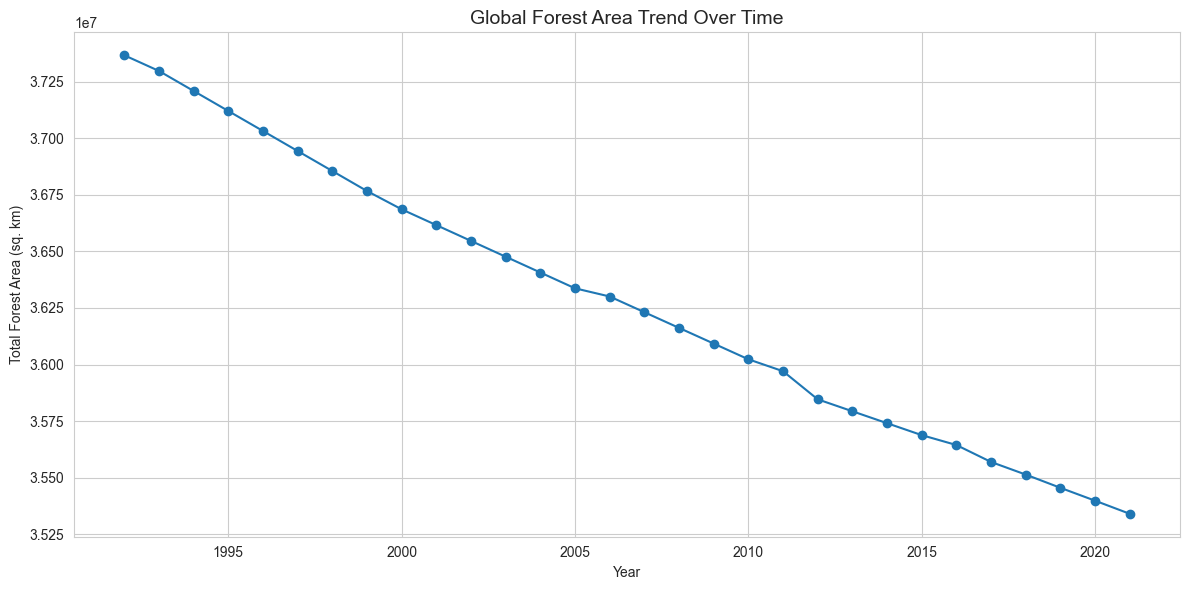

In [33]:
global_forest_trend = forest_long[
    forest_long["Year"] >= 1992
].groupby("Year")["Forest Area"].sum()

plt.figure(figsize=(12,6))
sns.set_style("whitegrid")

plt.plot(
    global_forest_trend.index,
    global_forest_trend.values,
    marker='o'
)

plt.title("Global Forest Area Trend Over Time", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Total Forest Area (sq. km)")
plt.grid(True)
plt.tight_layout()
plt.savefig("../visuals/global_forest_trend.png", bbox_inches="tight", dpi=300)
plt.show()

### Insight

Global forest area has consistently declined between 1992 and 2021, highlighting ongoing worldwide deforestation trends. The gradual downward slope indicates sustained forest depletion over multiple decades, likely driven by urbanization, agricultural expansion, industrial activities, and land-use conversion.
The analysis emphasizes the long-term environmental impact of economic development and population growth on global forest ecosystems.

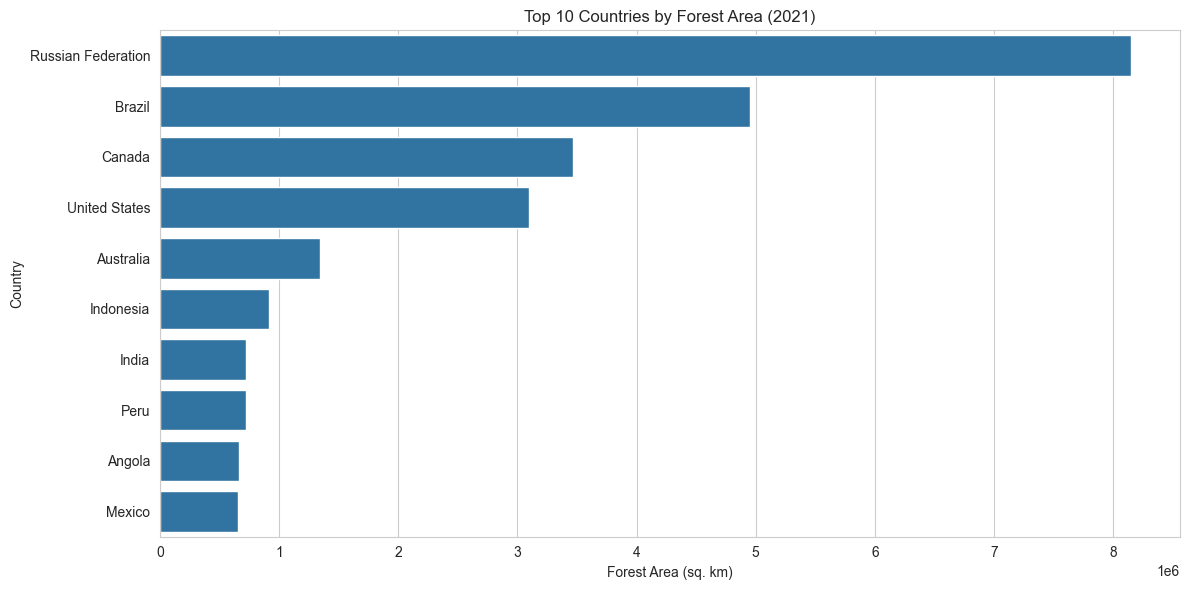

In [ ]:
latest_year = forest_long["Year"].max()

top_forest = (
    forest_long[forest_long["Year"] == latest_year]
    .sort_values("Forest Area", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
sns.set_style("whitegrid")
sns.barplot(
    data=top_forest,
    x="Forest Area",
    y="Country Name"
)

plt.title(f"Top 10 Countries by Forest Area ({latest_year})")
plt.xlabel("Forest Area (sq. km)")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig("../visuals/top10_forest_country.png", bbox_inches="tight", dpi=300)
plt.show()

### Insight

The Russian Federation and Brazil possess the largest forest areas globally, reflecting the importance of boreal and tropical rainforest ecosystems. Countries with large geographical areas tend to maintain significantly higher forest cover compared to smaller nations.

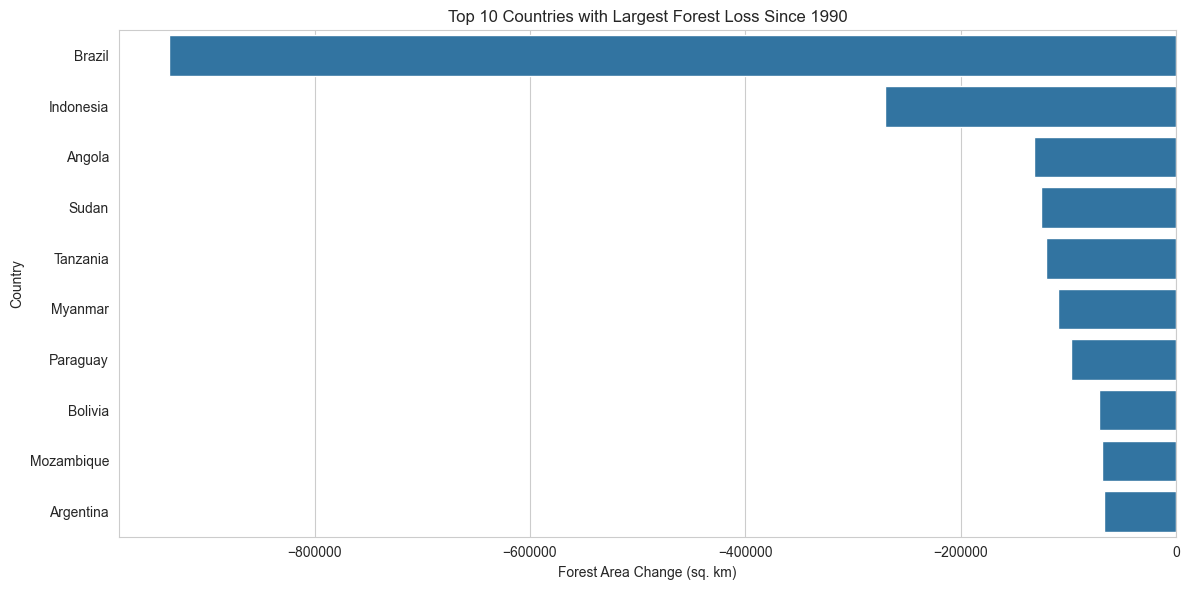

In [ ]:
forest_pivot = forest_long.pivot_table(
    index="Country Name",
    columns="Year",
    values="Forest Area"
)

forest_pivot["Forest Change"] = (
    forest_pivot[latest_year] - forest_pivot[1990]
)

largest_loss = (
    forest_pivot
    .sort_values("Forest Change")
    .head(10)
)

plt.figure(figsize=(12,6))
sns.set_style("whitegrid")
sns.barplot(
    x=largest_loss["Forest Change"],
    y=largest_loss.index
)

plt.title("Top 10 Countries with Largest Forest Loss Since 1990")
plt.xlabel("Forest Area Change (sq. km)")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig("../visuals/largest_forest_loss.png", bbox_inches="tight", dpi=300)
plt.show()

### Insight

Brazil experienced the largest forest area decline since 1990, indicating severe deforestation pressures in the Amazon region.
Indonesia also showed substantial forest loss, highlighting the environmental impact of industrial expansion and agricultural activities.

# GDP Growth vs Forest Area Correlation Analysis

In [14]:
merged_data = pd.merge(
    forest_long,
    gdp_long,
    on=["Country Name", "Year"],
    how="inner"
)
merged_data.head()

,Country Name,Country Code,Year,Forest Area,indicator_name,GDP Growth
0,Albania,ALB,1990,7888.0,Annual GDP growth (percent change),-10.0
1,Algeria,DZA,1990,16670.0,Annual GDP growth (percent change),0.8
2,Angola,AGO,1990,792627.8,Annual GDP growth (percent change),-3.5
3,Antigua and Barbuda,ATG,1990,101.1,Annual GDP growth (percent change),3.0
4,Argentina,ARG,1990,352040.0,Annual GDP growth (percent change),-1.3


In [15]:
merged_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5151 entries, 0 to 5150
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    5151 non-null   str    
 1   Country Code    5151 non-null   str    
 2   Year            5151 non-null   int64  
 3   Forest Area     5151 non-null   float64
 4   indicator_name  5151 non-null   str    
 5   GDP Growth      5151 non-null   float64
dtypes: float64(2), int64(1), str(3)
memory usage: 241.6 KB


In [16]:
merged_data.shape

(5151, 6)

## Correlation Analysis

In [17]:
correlation = merged_data[
    ["Forest Area", "GDP Growth"]
].corr()

print(correlation)

             Forest Area  GDP Growth
Forest Area     1.000000   -0.026538
GDP Growth     -0.026538    1.000000


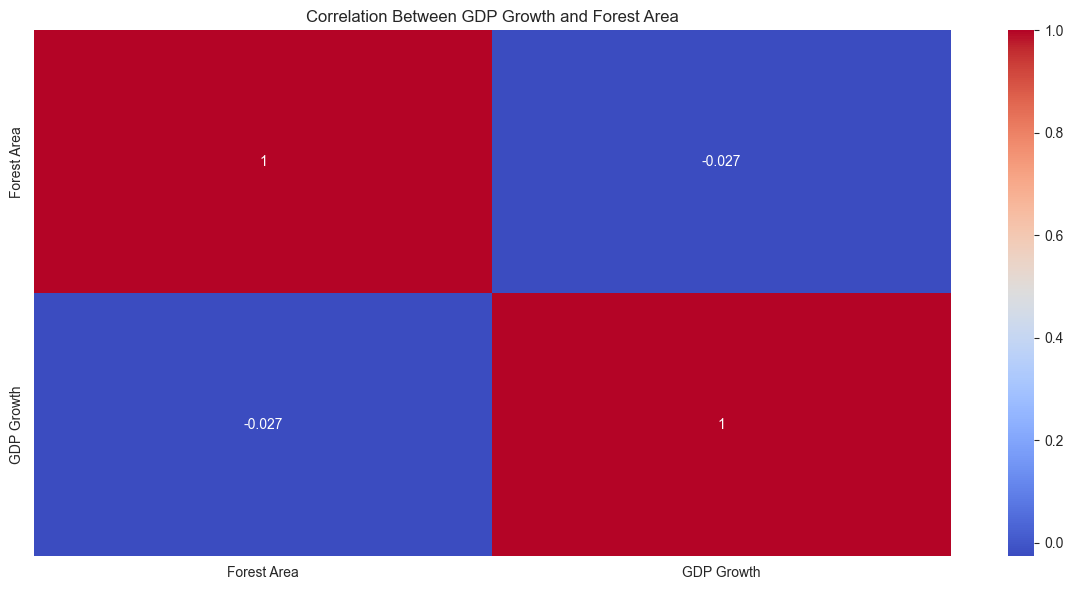

In [30]:
#HeatMap
plt.figure(figsize=(12,6))
sns.set_style("whitegrid")
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between GDP Growth and Forest Area")
plt.tight_layout()
plt.savefig(
    "../visuals/gdp_forest_correlation_heatmap.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

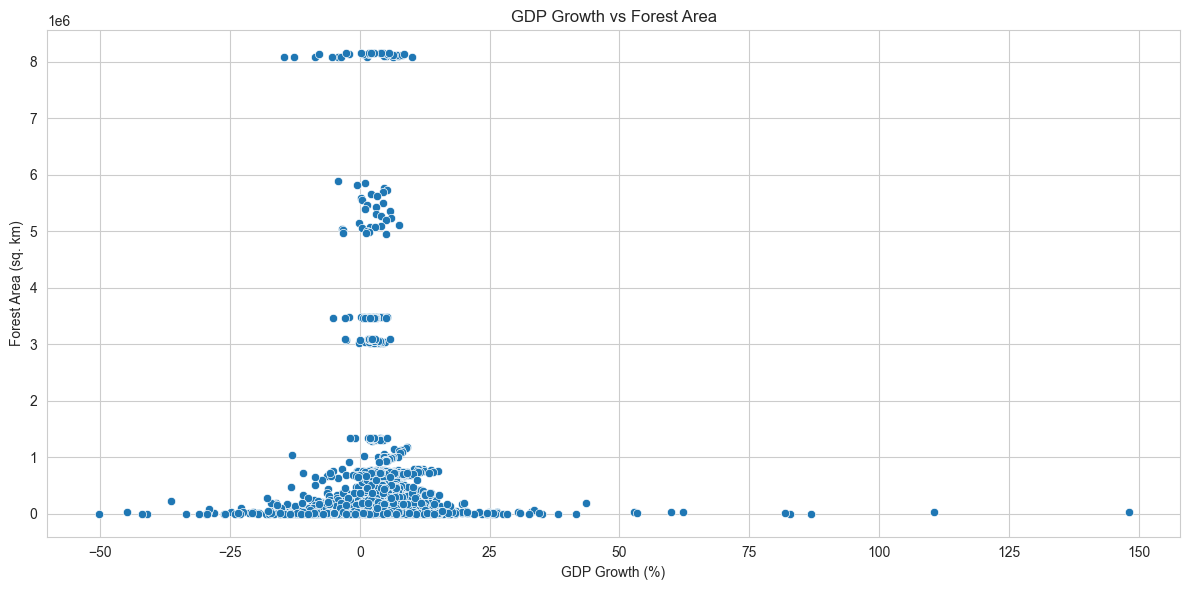

In [ ]:
#GDP Growth vs Forest Area Scatter Analysis
plt.figure(figsize=(12,6))
sns.set_style("whitegrid")
sns.scatterplot(
    data=merged_data,
    x="GDP Growth",
    y="Forest Area"
)

plt.title("GDP Growth vs Forest Area")
plt.xlabel("GDP Growth (%)")
plt.ylabel("Forest Area (sq. km)")
plt.tight_layout()
plt.savefig(
    "../visuals/gdp_vs_forest_scatter.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

### Insight

The correlation coefficient between GDP growth and forest area was approximately -0.027, indicating an extremely weak negative relationship.

This suggests that economic growth alone does not strongly determine changes in forest area.
Deforestation trends are likely influenced by multiple interconnected factors such as agricultural expansion, industrialization, environmental policies, urbanization, resource extraction, and conservation efforts.

The scatter plot further confirms the absence of a strong linear relationship between GDP growth and forest area across countries.

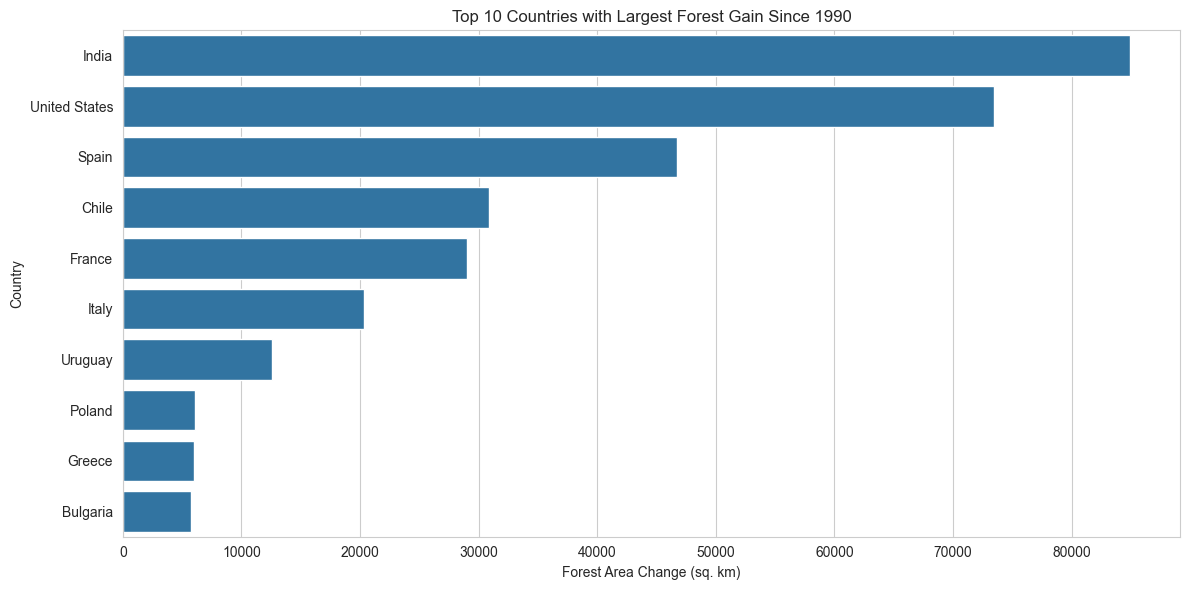

In [35]:
#Forest Gain Analysis
largest_gain = (
    forest_pivot
    .sort_values("Forest Change", ascending=False)
    .head(10)
)
plt.figure(figsize=(12,6))
sns.set_style("whitegrid")
sns.barplot(
    x=largest_gain["Forest Change"],
    y=largest_gain.index
)

plt.title("Top 10 Countries with Largest Forest Gain Since 1990")
plt.xlabel("Forest Area Change (sq. km)")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig(
    "../visuals/largest_forest_gain.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

### Insight

Several countries demonstrated positive forest area growth between 1990 and 2021, indicating successful afforestation, reforestation, and conservation initiatives.
These gains may reflect stronger environmental policies, sustainable land management, and national forest restoration programs.

# Final Conclusion

This analysis shows that global forest area has steadily declined from 1992 to 2021, indicating long-term deforestation trends across the world.

Countries such as Brazil and Indonesia experienced major forest loss, highlighting environmental pressure from agriculture, industrial expansion, and land-use change.

The GDP growth correlation analysis showed a very weak negative correlation with forest area, suggesting that economic growth alone does not explain deforestation. Forest loss is influenced by multiple factors such as policy decisions, conservation efforts, urbanization, and industrial activities.

Overall, the project highlights the importance of sustainable development, forest conservation, and data-driven environmental monitoring.